# AIE S2 — Bank Term Deposit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s2-bank-marketing.ipynb)

**Classification.** A Portuguese bank ran a direct marketing
campaign: 45,211 calls, and for each one, whether the client
subscribed a term deposit afterwards. Predict that outcome for calls
you have not been shown.

Challenge: <https://ml-arena.com/viewchallenge/184>

---

**This notebook contains no code, and that is deliberate.** You have
just read the bike-demand notebook, which is the same five steps on a
regression target. Here the steps are written out in English and the
cells are empty. Write them yourself.

Two things genuinely differ from the bike challenge, and both are
flagged below where they bite: the target is a **class**, not a
quantity, and it is **imbalanced** — only 11.7% of clients said yes.

---

## 0. Setup

Install the ML-Arena client. `pandas`, `seaborn` and `scikit-learn`
are already available in Colab.

The distribution is **`mlarena-sdk`** and it imports as `mlarena`.
`pip install mlarena` installs an unrelated package — check you have
the right one.

In [9]:
!pip install -q mlarena-sdk

import seaborn as sns
import matplotlib.pyplot as plt


---

## 1. Get the data

Connect with your personal `mlk_user_...` key from your ML-Arena
Profile page, and download the dataset for challenge **184**
into the working directory. Same two calls as last time.

In [10]:
import mlarena

API_KEY = "mlk_user_eeea0ac9a93256a6_798bce620dcbae5a7efe3bbf16a73f7d"   # <- paste yours here
CHALLENGE_ID = 184

client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./X_train.csv', './X_test.csv', './y_train.csv']

---

## 2. Read it

Load `X_train.csv`, the `prediction` column of `y_train.csv`, and
`X_test.csv`.

Then answer three questions before going further:

- What are **n** and **p**?
- Which columns are numeric and which are text?
- **What fraction of the training target is 1?** Compute it now. This
  number decides your metric and your reading of every result that
  follows.

In [11]:
import pandas as pd

X = pd.read_csv("X_train.csv")               # the hours you have a label for
y = pd.read_csv("y_train.csv")["prediction"]
X_submission = pd.read_csv("X_test.csv")     # the hours the leaderboard scores

print("X", X.shape, " X_submission", X_submission.shape, "y", y.shape)

X (36168, 17)  X_submission (9043, 17) y (36168,)


# FEATURE INGENERING

In [12]:
def calculate_day_of_week(day, month): #donne juste un chiffre de 0 à 6 correspondant au jour de la semaine en partant du 1er janvier
    month_number= {"jan" : 0, "feb" : 1, "mar" : 2, "apr" : 3, "may" : 4, "jun" : 5, "jul" : 6, "aug" : 7, "sep" : 8, "oct" : 9, "nov" : 10, "dec" : 11}
    month_days = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    return (day + sum(month_days[:month_number[month]]) -4) % 7

In [13]:
#on ajoute la colonne day_of_week à X et X_submission
X["day_of_week"] = X.apply(lambda row: calculate_day_of_week(row["day"], row["month"]), axis=1)
X_submission["day_of_week"] = X_submission.apply(lambda row: calculate_day_of_week(row["day"], row["month"]), axis=1)

In [14]:
X.describe()

,age,balance,day,duration,campaign,pdays,previous,day_of_week
count,36168.000000,36168.00000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.892999,1365.49342,15.817961,258.506940,2.763935,40.157238,0.581730,3.555380
std,10.627075,3068.54350,8.331980,259.142445,3.104161,100.162614,2.408766,1.548464
min,18.000000,-8019.00000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,74.00000,8.000000,103.000000,1.000000,-1.000000,0.000000,2.000000
50%,39.000000,451.00000,16.000000,180.000000,2.000000,-1.000000,0.000000,4.000000
75%,48.000000,1430.25000,21.000000,318.000000,3.000000,-1.000000,0.000000,5.000000
max,95.000000,102127.00000,31.000000,4918.000000,63.000000,871.000000,275.000000,6.000000


Text(0.5, 1.0, 'Distribution of Balance (Log Transformed)')

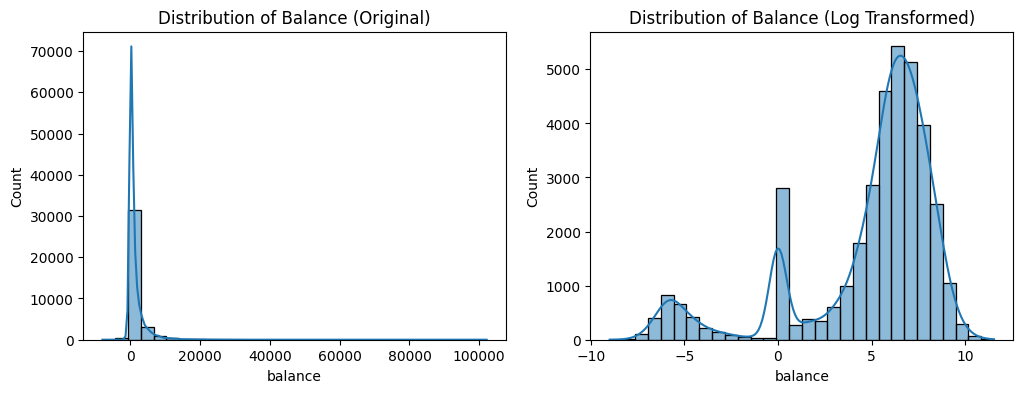

In [22]:
#on regarde la répartition de " balance " dans le dataset X
#on compare avant et après le log pour voir si la distribution est plus normale

import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X['balance'], bins=30, kde=True, ax=axs[0])
axs[0].set_title('Distribution of Balance (Original)')
sns.histplot (np.sign(X["balance"]) * np.log1p(np.abs(X["balance"])), bins=30, kde=True, ax=axs[1])
axs[1].set_title('Distribution of Balance (Log Transformed)') 

In [ ]:
import numpy as np
import pandas as pd

def balance_bins(df):
    balance_log = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

    result = pd.Series("zero", index=df.index, dtype="object")

    negative_bins = pd.cut(
        balance_log,
        bins=[-np.inf, -8, -6, -4, -2, -1, -0.1, 0],
        labels=[
            "neg_very_large",
            "neg_large",
            "neg_medium",
            "neg_small",
            "neg_very_small",
            "neg_near_zero",
            "neg_tiny",
        ]
    )

    positive_bins = pd.cut(
        balance_log,
        bins=[0, 0.1, 1, 2, 4, 6, 8, 10, np.inf],
        labels=[
            "pos_near_zero",
            "pos_very_small",
            "pos_small",
            "pos_medium",
            "pos_large",
            "pos_very_large",
            "pos_extreme",
            "pos_max",
        ]
    )

    negative_mask = balance_log < 0
    positive_mask = balance_log > 0
    result.loc[negative_mask] = negative_bins.loc[negative_mask].astype(str)
    result.loc[positive_mask] = positive_bins.loc[positive_mask].astype(str)

    return result

X["balance_is_zero"] = (X["balance"] == 0).astype(int)
X_submission["balance_is_zero"] = (
    X_submission["balance"] == 0
).astype(int)

X["balance_bin"] = balance_bins(X)
X_submission["balance_bin"] = balance_bins(X_submission)

---

## 4. Turn it into numbers

Same problem as before: nine of the sixteen columns are text. One-hot
encode them, and align the test columns to the training ones — an
encoding done independently on the two frames will not match.

**Then scale the numeric columns.** This is the step the bike notebook
did not need. `balance` runs from −8,019 to 102,127 while `campaign`
runs from 1 to 63; the solver behind `LogisticRegression` will not
converge in a sensible number of iterations if you hand it both
untouched. `StandardScaler` fitted on the training matrix is enough.

**A decision to make here.** `duration` is the length of the call you
are predicting the outcome of. You only know it once the call has
ended — so a model that relies on it could never run *before* placing
the call. It is in the data and you may use it. Decide whether you
want to, and say why in a comment. Both answers are defensible; an
unexamined answer is not.

---

## 5. Fit it and read the numbers

Fit `LogisticRegression` on the training matrix and score it on those
same rows. As in the bike notebook, that is deliberate: this session
measures the fit on the data it was fitted to, which a model with one
coefficient per column can be trusted to answer honestly. Session 3 is
where you learn to measure it properly.

Report **four** numbers: accuracy, precision, recall and F1. Then:

- Compare your accuracy with the always-predict-0 accuracy from step
  3a. If they are close, your accuracy is telling you nothing.
- Look at precision against recall. A model that almost never predicts
  1 will have decent precision and terrible recall, and F1 is the
  number that refuses to let you ignore that.
- A confusion matrix makes all four legible at once. Plot it.

The challenge ranks on **F1 on the positive class**, for exactly the
reason step 3a made visible.

---

## 6. The threshold is yours

`predict()` labels a client as 1 when the predicted probability
exceeds 0.5. That 0.5 is a convention, not a property of the problem,
and on a target that is 11.7% positive it is rarely the best choice.

Use `predict_proba()` to get the probabilities, then:

- Sweep the threshold from 0.05 to 0.60 and plot F1 against it.
- Read off the best one and keep it.

On this dataset the move is worth more than changing model family —
it is worth about **0.13 of F1**, and no model in Session 3 will buy
you that. Sweep it here, in the notebook; the leaderboard gives you
one number per submission and is not a search space.

---

## 7. Go further: put the shapes you saw into the columns

The threshold was the cheap move and you have spent it. What is left
is the move the model cannot make for itself.

`LogisticRegression` gets **one coefficient per column**. About a
numeric column it can therefore say exactly two things — *more is
likelier* or *less is likelier* — and nothing else. Go back to your
plots from step 3 and ask of each one: **can a single coefficient say
this?** Where it cannot, the fix is a column, not a bigger model.

Three of your figures should already have answered no. Cutting a
column into bins and letting `get_dummies` make one indicator per
bin gives the model a free number per bin, which is exactly the
shape a rate plot that goes down and then up requires.

Then look for the other two moves from the *Data Preparation*
lesson: a **transform** for a column whose scale is wildly skewed,
and an **interaction** where the effect of one column plainly depends
on another.

**Check before you add.** `get_dummies` has already been at the nine
text columns, and one flag you may be about to build by hand is
sitting in that matrix twice already. Compare `X.pdays == -1` against
`poutcome == 'unknown'` and against `previous == 0` before you write
the line — one of those agreements is exact and the other is off by
five rows in 36,168. A column that duplicates one you have buys
nothing and costs you a coefficient.

**Measure one move at a time**, and re-run your step-6 threshold
sweep after each: a change that helps at a fixed 0.5 can be worth
nothing once the threshold is free to move, and you cannot tell which
happened if you changed six columns at once. Keep a move only if it
moves the F1.

For calibration: the baseline with a tuned threshold lands near
**F1 = 0.58**, and re-cut columns are worth roughly
**+0.01 to +0.02** on top of it. That is a smaller gain than the
threshold bought you, and it is the honest size of the effect —
the point of the step is the reasoning, not the third decimal.

---

## 8. Predict the test set and write the submission

Refit on all the training data — with whatever column recipe you
kept from step 7, applied identically to `X_test` — predict, and
apply the threshold you chose.

The submission is `submission.csv` with columns `id` and `prediction`,
one row per test id. **`prediction` must be the integer 0 or 1** — a
probability is rejected outright rather than thresholded for you.

Assert the three things before uploading: one row per test id, ids
unique, and every value in {0, 1}.

---

## 9. Submit

Submit the file and look at the leaderboard. The challenge page has
the ladder to read yourself against: F1 = 0.453 is the baseline at
the default threshold, 0.581 is that same model at 0.20, and 0.592
is it again on re-cut columns.

Below 0.453, the likely reasons in order: you left the threshold at
0.5, you did not scale, or your test columns are misaligned with your
training columns. Around 0.58 you found the threshold. Above that you
found something in step 7 as well.

---

## 10. Write down what you did

Two or three sentences, in the notebook:

- Which metric you are reporting and why that one.
- What you did about `duration`, and why.
- What threshold you chose, and what it cost you in precision to buy
  that recall.
- Which column changes you kept, which you tried and dropped, and
  what the F1 said about each.

Being able to answer those is the point of the exercise. The score is
just the receipt.